## Import Libraries

In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler
)

from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    ConfusionMatrixDisplay
)
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

## Load Feature Engineered Dataset

In [6]:
DATA_PATH = r"D:\Telco_Customer_Churn\data\processed_data\churn_feature_engineered.csv"
FIGURES_DIR = r"D:\Telco_Customer_Churn\reports\figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")
df.head(3)

Dataset loaded: 7043 rows x 25 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalServicesSubscribed,CustomerTenureGroup,CustomerValueTier,DigitalAdoptionScore
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,2,New Customer,Low Value,2
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,One year,No,Mailed check,56.95,1889.50,No,4,Regular Customer,Medium Value,1
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,4,New Customer,Low Value,3


# Dataset Overview

Understand the dataset before model training.

We will inspect:

- Dataset Shape
- Sample Records
- Data Types
- Missing Values

In [7]:
# Shape
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

# First five rows
df.head()

Rows    : 7043
Columns : 25


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalServicesSubscribed,CustomerTenureGroup,CustomerValueTier,DigitalAdoptionScore
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,2,New Customer,Low Value,2
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,One year,No,Mailed check,56.95,1889.50,No,4,Regular Customer,Medium Value,1
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,4,New Customer,Low Value,3
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,4,Regular Customer,Medium Value,1
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2,New Customer,Low Value,1


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerID               7043 non-null   str    
 1   gender                   7043 non-null   str    
 2   SeniorCitizen            7043 non-null   int64  
 3   Partner                  7043 non-null   str    
 4   Dependents               7043 non-null   str    
 5   tenure                   7043 non-null   int64  
 6   PhoneService             7043 non-null   str    
 7   MultipleLines            7043 non-null   str    
 8   InternetService          7043 non-null   str    
 9   OnlineSecurity           7043 non-null   str    
 10  OnlineBackup             7043 non-null   str    
 11  DeviceProtection         7043 non-null   str    
 12  TechSupport              7043 non-null   str    
 13  StreamingTV              7043 non-null   str    
 14  StreamingMovies          7043 non-n

In [9]:
1
df.isnull().sum()

customerID                 0
gender                     0
SeniorCitizen              0
Partner                    0
Dependents                 0
tenure                     0
PhoneService               0
MultipleLines              0
InternetService            0
OnlineSecurity             0
OnlineBackup               0
DeviceProtection           0
TechSupport                0
StreamingTV                0
StreamingMovies            0
Contract                   0
PaperlessBilling           0
PaymentMethod              0
MonthlyCharges             0
TotalCharges               0
Churn                      0
TotalServicesSubscribed    0
CustomerTenureGroup        0
CustomerValueTier          0
DigitalAdoptionScore       0
dtype: int64

## Review Engineered Features

In [10]:
engineered_features = [
    'TotalServicesSubscribed',
    'CustomerTenureGroup',
    'CustomerValueTier',
    'DigitalAdoptionScore'
]

df[engineered_features].head()

,TotalServicesSubscribed,CustomerTenureGroup,CustomerValueTier,DigitalAdoptionScore
0,2,New Customer,Low Value,2
1,4,Regular Customer,Medium Value,1
2,4,New Customer,Low Value,3
3,4,Regular Customer,Medium Value,1
4,2,New Customer,Low Value,1


## Feature Selection

In [11]:
# Remove identifier column
df = df.drop(columns=['customerID'])

In [12]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalServicesSubscribed,CustomerTenureGroup,CustomerValueTier,DigitalAdoptionScore
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,2,New Customer,Low Value,2
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,One year,No,Mailed check,56.95,1889.50,No,4,Regular Customer,Medium Value,1
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,4,New Customer,Low Value,3
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,4,Regular Customer,Medium Value,1
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2,New Customer,Low Value,1


## Separate Features and Target

In [13]:
# Features
X = df.drop(columns=['Churn'])

# Target
y = df['Churn']

In [14]:
print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (7043, 23)
Target Shape   : (7043,)


In [15]:
print(X.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'TotalServicesSubscribed', 'CustomerTenureGroup', 'CustomerValueTier', 'DigitalAdoptionScore']


In [16]:
y.value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

## Train-Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
                                                X,
                                                y,
                                                test_size=0.2,
                                                random_state=42,
                                                stratify=y
                                            )

In [18]:
print(f"X train    : {X_train.shape}")
print(f"X test : {X_test.shape}")
print(f"Y Train    : {y_train.shape}")
print(f"Y test : {y_test.shape}")

X train    : (5634, 23)
X test : (1409, 23)
Y Train    : (5634,)
Y test : (1409,)


In [19]:
print(f"Y original  :  {y.value_counts()}")
print(f"Y train  :  {y_train.value_counts()}")
print(f"Y test  :  {y_test.value_counts()}")

Y original  :  Churn
No     5174
Yes    1869
Name: count, dtype: int64
Y train  :  Churn
No     4139
Yes    1495
Name: count, dtype: int64
Y test  :  Churn
No     1035
Yes     374
Name: count, dtype: int64


## Data Preprocessing

### Encode Target Variable


The target variable (`Churn`) contains categorical values:

- Yes
- No

Most machine learning algorithms in scikit-learn require the target variable to be numerical. Therefore, we encode:

- No → 0
- Yes → 1

This encoding is applied after the train-test split to maintain a clean and reproducible preprocessing workflow.

In [20]:
# Initialize Label Encoder
label_encoder = LabelEncoder()

In [21]:
# Encode the target variable

y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

In [22]:
# Verify encoded classes

print("Classes:", label_encoder.classes_)

Classes: ['No' 'Yes']


In [23]:
# Verify encoded target distribution

print("Training Target Distribution")
print(pd.Series(y_train).value_counts())

print("\nTesting Target Distribution")
print(pd.Series(y_test).value_counts())

Training Target Distribution
0    4139
1    1495
Name: count, dtype: int64

Testing Target Distribution
0    1035
1     374
Name: count, dtype: int64


### Identify Feature Types

Before preprocessing, we classify features based on their data type and business meaning.

This helps us apply the appropriate preprocessing technique to each group.

- **Numerical Features:** Continuous or count-based variables.
- **Binary Categorical Features:** Two possible categories (Yes/No, Male/Female).
- **Nominal Categorical Features:** Multiple categories with no natural order.
- **Ordinal Categorical Features:** Categories with a meaningful order.

In [24]:
# Numerical Features

numerical_features = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'TotalServicesSubscribed',
    'DigitalAdoptionScore'
]

print("Number of Numerical Features :", len(numerical_features))
print(numerical_features)

Number of Numerical Features : 5
['tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServicesSubscribed', 'DigitalAdoptionScore']


In [25]:
# Binary Categorical Features

binary_features = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]

print("Number of Binary Features :", len(binary_features))
print(binary_features)

Number of Binary Features : 6
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']


In [26]:
# Nominal Categorical Features

nominal_features = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

print("Number of Nominal Features :", len(nominal_features))
print(nominal_features)

Number of Nominal Features : 10
['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [27]:
# Ordinal Features

ordinal_features = [
    'CustomerTenureGroup',
    'CustomerValueTier'
]

print("Number of Ordinal Features :", len(ordinal_features))
print(ordinal_features)

Number of Ordinal Features : 2
['CustomerTenureGroup', 'CustomerValueTier']


In [28]:
total_features = (
    len(numerical_features)
    + len(binary_features)
    + len(nominal_features)
    + len(ordinal_features)
)

print("Total Features:", total_features)
print("Actual Features:", X_train.shape[1])

Total Features: 23
Actual Features: 23


## Build Preprocessing Pipelines

### Binary Feature Encoding

Gender
Partner
Dependents
PhoneService
PaperlessBilling
SeniorCitizen

In [29]:
# Binary Mapping

binary_mapping = {
    'Yes': 1,
    'No': 0,
    'Male': 1,
    'Female': 0
}

In [30]:
binary_string_features = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]

In [31]:
for col in binary_string_features:
    X_train[col] = X_train[col].map(binary_mapping)
    X_test[col] = X_test[col].map(binary_mapping)

In [32]:
X_train[binary_string_features].head()

,gender,Partner,Dependents,PhoneService,PaperlessBilling
3738,1,0,0,0,0
3151,1,1,1,1,0
4860,1,1,1,0,0
3867,0,1,0,1,1
3810,1,1,1,1,0


In [33]:
X_train[binary_string_features].nunique()

gender              2
Partner             2
Dependents          2
PhoneService        2
PaperlessBilling    2
dtype: int64

In [36]:
for col in binary_string_features:
    print(f"{col}: {X_train[col].unique()}")

gender: [1 0]
Partner: [0 1]
Dependents: [0 1]
PhoneService: [0 1]
PaperlessBilling: [0 1]


# Ordinal Encoding

Ordinal features have categories with a meaningful order.

Examples:

CustomerTenureGroup

New Customer → Regular Customer → Loyal Customer

CustomerValueTier

Low Value → Medium Value → High Value

Since these categories have a natural ranking, we preserve this order by assigning increasing numerical values.

In [37]:
# Customer Tenure Group Mapping

tenure_mapping = {
    'New Customer': 0,
    'Regular Customer': 1,
    'Loyal Customer': 2
}

In [38]:
# Customer Value Tier Mapping

value_mapping = {
    'Low Value': 0,
    'Medium Value': 1,
    'High Value': 2
}

In [39]:
# Apply Ordinal Encoding

X_train['CustomerTenureGroup'] = X_train['CustomerTenureGroup'].map(tenure_mapping)
X_test['CustomerTenureGroup'] = X_test['CustomerTenureGroup'].map(tenure_mapping)

X_train['CustomerValueTier'] = X_train['CustomerValueTier'].map(value_mapping)
X_test['CustomerValueTier'] = X_test['CustomerValueTier'].map(value_mapping)

In [40]:
# Check first few rows

X_train[['CustomerTenureGroup', 'CustomerValueTier']].head()

,CustomerTenureGroup,CustomerValueTier
3738,1,1
3151,1,1
4860,1,0
3867,1,1
3810,0,0


In [41]:
print("CustomerTenureGroup :", sorted(X_train['CustomerTenureGroup'].unique()))
print("CustomerValueTier   :", sorted(X_train['CustomerValueTier'].unique()))

CustomerTenureGroup : [np.int64(0), np.int64(1), np.int64(2)]
CustomerValueTier   : [np.int64(0), np.int64(1), np.int64(2)]


In [43]:
# Check for missing values after mapping

print(X_train[['CustomerTenureGroup', 'CustomerValueTier']].isnull().sum())

print(X_test[['CustomerTenureGroup', 'CustomerValueTier']].isnull().sum())

CustomerTenureGroup    0
CustomerValueTier      0
dtype: int64
CustomerTenureGroup    0
CustomerValueTier      0
dtype: int64


# One-Hot Encoding

Nominal categorical features do not have a natural order.

Examples:

- Internet Service
- Payment Method
- Contract
- Multiple Lines

Assigning numerical values such as:

Electronic Check = 0
Mailed Check = 1
Bank Transfer = 2

would incorrectly imply that one category is greater than another.

One-Hot Encoding creates a separate binary column for each category, allowing machine learning models to treat each category independently.

In [44]:
nominal_features = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

print(nominal_features)

['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [45]:
# Initialize One-Hot Encoder

onehot_encoder = OneHotEncoder(
    drop='first',
    handle_unknown='ignore',
    sparse_output=False
)

In [46]:
# Learn categories from training data

X_train_encoded = onehot_encoder.fit_transform(
    X_train[nominal_features]
)

In [47]:
# Apply learned categories to test data

X_test_encoded = onehot_encoder.transform(
    X_test[nominal_features]
)

In [48]:
encoded_feature_names = onehot_encoder.get_feature_names_out(
    nominal_features
)

In [49]:
X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoded_feature_names,
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoded_feature_names,
    index=X_test.index
)

In [50]:
X_train = X_train.drop(columns=nominal_features)
X_test = X_test.drop(columns=nominal_features)

In [51]:
X_train = pd.concat(
    [X_train, X_train_encoded],
    axis=1
)

X_test = pd.concat(
    [X_test, X_test_encoded],
    axis=1
)

In [52]:
print("Train Shape :", X_train.shape)
print("Test Shape  :", X_test.shape)

Train Shape : (5634, 34)
Test Shape  : (1409, 34)


In [53]:
print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())

0
0


In [54]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 5634 entries, 3738 to 5639
Data columns (total 34 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 5634 non-null   int64  
 1   SeniorCitizen                          5634 non-null   int64  
 2   Partner                                5634 non-null   int64  
 3   Dependents                             5634 non-null   int64  
 4   tenure                                 5634 non-null   int64  
 5   PhoneService                           5634 non-null   int64  
 6   PaperlessBilling                       5634 non-null   int64  
 7   MonthlyCharges                         5634 non-null   float64
 8   TotalCharges                           5634 non-null   float64
 9   TotalServicesSubscribed                5634 non-null   int64  
 10  CustomerTenureGroup                    5634 non-null   int64  
 11  CustomerValueTier

In [55]:
print(X_train.shape)
print(X_test.shape)
print(X_train.info())

(5634, 34)
(1409, 34)
<class 'pandas.DataFrame'>
Index: 5634 entries, 3738 to 5639
Data columns (total 34 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 5634 non-null   int64  
 1   SeniorCitizen                          5634 non-null   int64  
 2   Partner                                5634 non-null   int64  
 3   Dependents                             5634 non-null   int64  
 4   tenure                                 5634 non-null   int64  
 5   PhoneService                           5634 non-null   int64  
 6   PaperlessBilling                       5634 non-null   int64  
 7   MonthlyCharges                         5634 non-null   float64
 8   TotalCharges                           5634 non-null   float64
 9   TotalServicesSubscribed                5634 non-null   int64  
 10  CustomerTenureGroup                    5634 non-null   int64  


# Feature Scaling

Machine learning algorithms such as Logistic Regression are sensitive to the scale of numerical features.

For example:

- tenure ranges from 0 to 72
- TotalCharges ranges from 0 to 8000+

Without scaling, features with larger values can dominate the learning process.

Tree-based algorithms such as Decision Tree and Random Forest do not require feature scaling because they split data based on thresholds rather than distances.

Therefore, scaling will only be applied to the Logistic Regression pipeline.

In [56]:
# Initialize Standard Scaler

scaler = StandardScaler()

In [57]:
# Create copies for Logistic Regression

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

In [58]:
# Scale numerical features

X_train_scaled[numerical_features] = scaler.fit_transform(
    X_train[numerical_features]
)

X_test_scaled[numerical_features] = scaler.transform(
    X_test[numerical_features]
)

In [59]:
X_train[numerical_features].describe()

,tenure,MonthlyCharges,TotalCharges,TotalServicesSubscribed,DigitalAdoptionScore
count,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000
mean,32.485091,64.929961,2299.334682,4.167554,2.010827
std,24.568744,30.138105,2279.204278,2.320947,1.489316
min,0.000000,18.400000,0.000000,1.000000,0.000000
25%,9.000000,35.662500,402.975000,2.000000,1.000000
50%,29.000000,70.500000,1394.925000,4.000000,2.000000
75%,55.000000,90.000000,3835.825000,6.000000,3.000000
max,72.000000,118.750000,8684.800000,9.000000,5.000000


In [60]:
X_train_scaled[numerical_features].describe().round(2)

,tenure,MonthlyCharges,TotalCharges,TotalServicesSubscribed,DigitalAdoptionScore
count,5634.00,5634.00,5634.00,5634.00,5634.00
mean,-0.00,-0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00
min,-1.32,-1.54,-1.01,-1.36,-1.35
25%,-0.96,-0.97,-0.83,-0.93,-0.68
50%,-0.14,0.18,-0.40,-0.07,-0.01
75%,0.92,0.83,0.67,0.79,0.66
max,1.61,1.79,2.80,2.08,2.01


In [61]:
X_train[['gender', 'Partner', 'Contract_One year']].head()

,gender,Partner,Contract_One year
3738,1,0,0.0
3151,1,1,0.0
4860,1,1,0.0
3867,0,1,0.0
3810,1,1,0.0


In [62]:
X_train_scaled[['gender', 'Partner', 'Contract_One year']].head()

,gender,Partner,Contract_One year
3738,1,0,0.0
3151,1,1,0.0
4860,1,1,0.0
3867,0,1,0.0
3810,1,1,0.0


In [63]:
print("Original Dataset Shape :", X_train.shape)
print("Scaled Dataset Shape   :", X_train_scaled.shape)

Original Dataset Shape : (5634, 34)
Scaled Dataset Shape   : (5634, 34)


In [65]:
X_train_scaled


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,TotalServicesSubscribed,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,1,0,0,0,0.102371,0,0,-0.521976,-0.262257,-0.072199,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3151,1,0,1,1,-0.711743,1,0,0.337478,-0.503635,-0.503095,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4860,1,0,1,1,-0.793155,0,0,-0.809013,-0.749883,-0.072199,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3867,0,0,1,0,-0.263980,1,1,0.284384,-0.172722,0.789595,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
3810,1,0,1,1,-1.281624,1,0,-0.676279,-0.989374,-0.933992,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6303,0,0,1,0,1.567778,1,0,1.470695,2.373129,1.651389,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
6227,1,0,0,0,-1.240918,1,0,-0.626504,-0.973665,-0.933992,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4673,0,1,0,0,-0.304686,1,1,1.256662,0.158344,1.220492,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2710,0,0,1,0,-0.345392,1,0,-1.477661,-0.797075,-1.364889,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [66]:
X_test_scaled

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,TotalServicesSubscribed,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
437,1,0,1,1,1.608483,1,1,1.629976,2.706828,2.082285,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
2280,0,1,0,0,-0.996684,1,1,1.168725,-0.610260,0.789595,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2235,0,0,1,1,0.346606,1,1,0.445324,0.400116,1.220492,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4460,1,0,1,0,-0.589626,1,0,0.440347,-0.364451,-0.072199,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3761,0,0,1,0,1.608483,1,1,0.588013,1.588421,1.651389,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5143,0,0,1,1,0.672252,1,1,0.738999,0.897615,1.651389,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
4439,1,0,1,1,-0.182569,1,1,-1.480980,-0.794815,-1.364889,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
3857,1,0,0,0,-1.118801,1,0,-1.469365,-0.967873,-1.364889,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4758,0,0,0,0,0.957192,1,0,-1.500890,-0.547360,-1.364889,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [67]:
X_train


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,TotalServicesSubscribed,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,1,0,0,0,35,0,0,49.20,1701.65,4,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3151,1,0,1,1,15,1,0,75.10,1151.55,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4860,1,0,1,1,13,0,0,40.55,590.35,4,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3867,0,0,1,0,26,1,1,73.50,1905.70,6,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
3810,1,0,1,1,1,1,0,44.55,44.55,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6303,0,0,1,0,71,1,0,109.25,7707.70,8,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
6227,1,0,0,0,2,1,0,46.05,80.35,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4673,0,1,0,0,25,1,1,102.80,2660.20,7,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2710,0,0,1,0,24,1,0,20.40,482.80,1,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [68]:
X_test

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,TotalServicesSubscribed,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
437,1,0,1,1,72,1,1,114.05,8468.20,9,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
2280,0,1,0,0,8,1,1,100.15,908.55,6,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2235,0,0,1,1,41,1,1,78.35,3211.20,7,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4460,1,0,1,0,18,1,0,78.20,1468.75,4,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3761,0,0,1,0,72,1,1,82.65,5919.35,8,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5143,0,0,1,1,49,1,1,87.20,4345.00,8,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
4439,1,0,1,1,28,1,1,20.30,487.95,1,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
3857,1,0,0,0,5,1,0,20.65,93.55,1,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4758,0,0,0,0,56,1,0,19.70,1051.90,1,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


# Logistic Regression

## Objective

Logistic Regression is used as the baseline classification model.

Although its name contains "Regression", it is designed for binary classification problems.

The model estimates the probability that a customer belongs to the churn class.

This model is sensitive to feature scaling; therefore, the scaled dataset is used for training.

In [70]:
# Initialize Logistic Regression Model

log_reg = LogisticRegression(
    random_state=42
)

In [71]:
# Train the model

log_reg.fit(
    X_train_scaled,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [72]:
# Predict class labels

y_pred_lr = log_reg.predict(
    X_test_scaled
)

In [73]:
# Predict probabilities

y_prob_lr = log_reg.predict_proba(
    X_test_scaled
)

In [74]:
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

In [75]:
print("Training Score :", log_reg.score(X_train_scaled, y_train))
print("Testing Score  :", log_reg.score(X_test_scaled, y_test))

Training Score : 0.8056443024494143
Testing Score  : 0.7998580553584103


In [76]:
print("Training Accuracy :", log_reg.score(X_train_scaled, y_train))
print("Testing Accuracy  :", log_reg.score(X_test_scaled, y_test))

Training Accuracy : 0.8056443024494143
Testing Accuracy  : 0.7998580553584103


## Model Evaluation

# Confusion Matrix

A confusion matrix summarizes the performance of a classification model by comparing the predicted classes with the actual classes.

It provides four outcomes:

- True Positive (TP)
- True Negative (TN)
- False Positive (FP)
- False Negative (FN)

Every classification metric such as Accuracy, Precision, Recall, and F1 Score is derived from these four values.

In [77]:
# Generate Confusion Matrix

cm = confusion_matrix(y_test, y_pred_lr)

cm

array([[927, 108],
       [174, 200]])

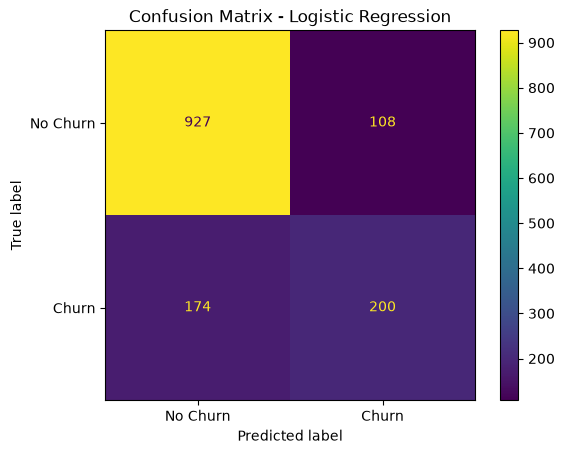

In [78]:
# Display Confusion Matrix

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
).plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [79]:
# Accuracy

accuracy = accuracy_score(y_test, y_pred_lr)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.7999


In [80]:
# Precision

precision = precision_score(y_test, y_pred_lr)

print(f"Precision : {precision:.4f}")

Precision : 0.6494


In [81]:
# Recall

recall = recall_score(y_test, y_pred_lr)

print(f"Recall : {recall:.4f}")

Recall : 0.5348


In [82]:
# F1 Score

f1 = f1_score(y_test, y_pred_lr)

print(f"F1 Score : {f1:.4f}")

F1 Score : 0.5865


In [83]:
# ROC-AUC Score

roc_auc = roc_auc_score(
    y_test,
    y_prob_lr
)

print(f"ROC-AUC : {roc_auc:.4f}")

ROC-AUC : 0.8412


In [84]:
# Classification Report

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.65      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



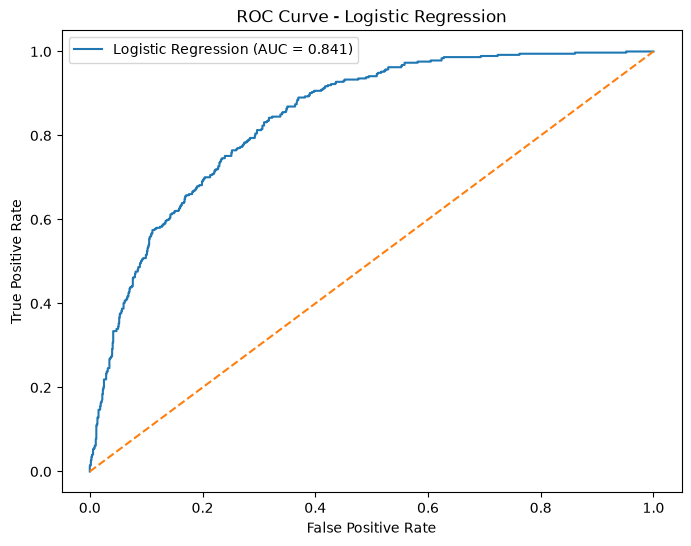

In [85]:
# Calculate ROC Curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_lr
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

In [86]:
# Performance Summary

performance_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

performance_summary

,Metric,Score
0,Accuracy,0.799858
1,Precision,0.649351
2,Recall,0.534759
3,F1 Score,0.586510
4,ROC-AUC,0.841228


## Business Interpretation

- The model achieved an accuracy of **79%** on unseen customer data.
- Recall indicates that the model correctly identified **53%** of customers who actually churned.
- Precision indicates that **64%** of customers predicted as churners actually churned.
- The ROC-AUC score demonstrates the model's ability to distinguish between churn and non-churn customers across different probability thresholds.
- This model serves as a baseline for comparison with more advanced models.

The Logistic Regression model generalizes well and provides a solid baseline, achieving approximately 80% accuracy and an ROC-AUC of 84%. It correctly identifies more than half of customers who will churn while maintaining reasonable precision. However, it still misses 174 out of 374 actual churners, indicating that recall should be improved before deployment. This model serves as a reliable benchmark against which more advanced models such as Random Forest and Gradient Boosting can be compared.

# Decision Tree Classifier

## Objective

Decision Trees classify customers by learning a sequence of decision rules based on feature values.

Unlike Logistic Regression, Decision Trees can capture non-linear relationships and interactions between features.

Since Decision Trees are not sensitive to feature scaling, the encoded (unscaled) dataset is used for training.

In [91]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

In [92]:
# Train Decision Tree

dt_model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [96]:
# class predition

y_pred_dt = dt_model.predict(X_test)

In [97]:
# probablitiy prediction

y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

### Training & Testing Accuracy

In [101]:
print(f"Train Accuracy : {dt_model.score(X_train, y_train): .4f}")
print(f"Test Accuracy : {dt_model.score(X_test, y_test): .4f}")


Train Accuracy :  0.9980
Test Accuracy :  0.7339


In [102]:
# Generate Confusion Matrix

cm = confusion_matrix(y_test, y_pred_dt)

cm

array([[857, 178],
       [197, 177]])

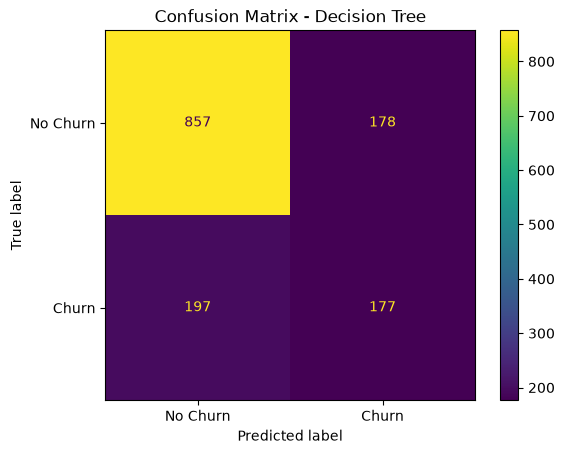

In [103]:
# Display Confusion Matrix

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
).plot()

plt.title("Confusion Matrix - Decision Tree")
plt.show()

In [104]:
# Accuracy

accuracy = accuracy_score(y_test, y_pred_dt)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.7339


In [105]:
# Precision

precision = precision_score(y_test, y_pred_dt)

print(f"Precision : {precision:.4f}")

Precision : 0.4986


In [106]:
# Recall

recall = recall_score(y_test, y_pred_dt)

print(f"Recall : {recall:.4f}")

Recall : 0.4733


In [107]:
# F1 Score

f1 = f1_score(y_test, y_pred_dt)

print(f"F1 Score : {f1:.4f}")

F1 Score : 0.4856


In [108]:
# ROC-AUC Score

roc_auc = roc_auc_score(
    y_test,
    y_prob_dt
)

print(f"ROC-AUC : {roc_auc:.4f}")

ROC-AUC : 0.6501


In [109]:
# Classification Report

print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.81      0.83      0.82      1035
       Churn       0.50      0.47      0.49       374

    accuracy                           0.73      1409
   macro avg       0.66      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409



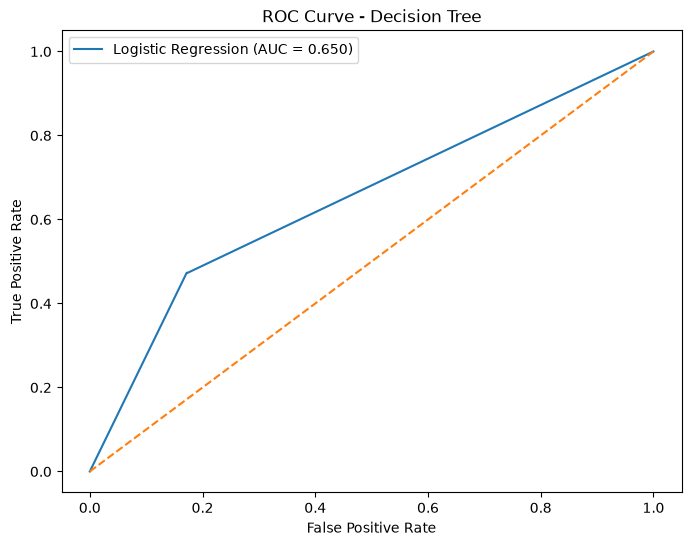

In [110]:
# Calculate ROC Curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_dt
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()

plt.show()

In [111]:
# Performance Summary

performance_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

performance_summary

,Metric,Score
0,Accuracy,0.733854
1,Precision,0.498592
2,Recall,0.473262
3,F1 Score,0.485597
4,ROC-AUC,0.650132


Although the Decision Tree achieved almost perfect training accuracy, its performance dropped significantly on the test dataset, indicating severe overfitting. Compared with Logistic Regression, it performed worse across every evaluation metric, including Accuracy, Precision, Recall, F1 Score, and ROC-AUC. Therefore, the default Decision Tree is not suitable for deployment and would require hyperparameter tuning to improve its ability to generalize.

# Random Forest Classifier

## Objective

Random Forest is an ensemble learning algorithm that combines the predictions of multiple Decision Trees.

Each tree is trained on a random subset of the training data and a random subset of features.

The final prediction is made using majority voting.

Compared with a single Decision Tree, Random Forest generally provides better generalization and is less prone to overfitting.

In [112]:
rf_model = RandomForestClassifier(
    random_state=42
)

In [113]:
rf_model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

### Prediciton

In [114]:
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [116]:
# Check Overfitting First
print("Training Accuracy :", rf_model.score(X_train,y_train))
print("Testing Accuracy :", rf_model.score(X_test,y_test))

Training Accuracy : 0.9980475683351083
Testing Accuracy : 0.7920511000709723


In [117]:
# Generate Confusion Matrix

cm = confusion_matrix(y_test, y_pred_rf)

cm

array([[931, 104],
       [189, 185]])

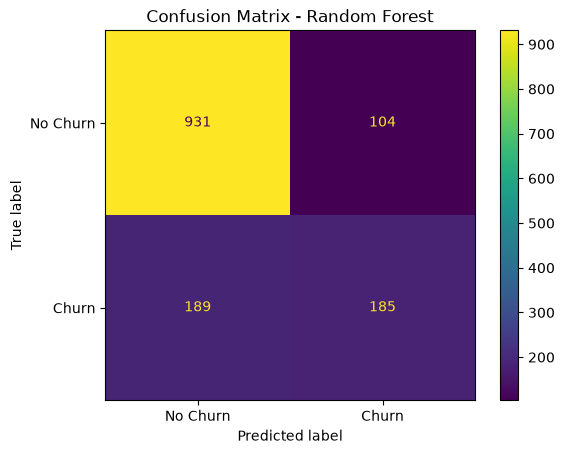

In [118]:
# Display Confusion Matrix

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
).plot()

plt.title("Confusion Matrix - Random Forest")
plt.show()

In [122]:
#Calculate metrics
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)
roc_auc = roc_auc_score(y_test, y_prob_rf)

In [123]:
#print metrics
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}\n")

Accuracy : 0.7921
Precision: 0.6401
Recall   : 0.4947
F1 Score : 0.5581
ROC-AUC  : 0.8210



In [124]:
# Print Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("\n")

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409





The Random Forest model improved significantly over the single Decision Tree, particularly in terms of test accuracy and ROC-AUC. However, compared with Logistic Regression, it did not provide better predictive performance. Logistic Regression achieved higher Recall, Precision, F1 Score, Accuracy, and ROC-AUC while also showing much better generalization. Therefore, at this stage, Logistic Regression remains the strongest candidate for deployment.

In [133]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

results = {}

for name, model in models.items():
    print(f"==================== {name} ====================")

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(X_test)

    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Store results
    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }

    # Print Confusion Matrix
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\n")

    # Print Classification Report
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("\n")

# Optional: View all results in a single DataFrame for easy comparison
results_df = pd.DataFrame(results).T
print("==================== SUMMARY TABLE ====================")
display(results_df)

==================== Logistic Regression ====================
Confusion Matrix:
[[930 105]
 [175 199]]


Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



==================== Decision Tree ====================
Confusion Matrix:
[[857 178]
 [197 177]]


Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82      1035
           1       0.50      0.47      0.49       374

    accuracy                           0.73      1409
   macro avg       0.66      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409



==================== Random Forest ====================
Confusion Matrix:
[[931 104]
 [189 1

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.801278,0.654605,0.532086,0.587021,0.841768
Decision Tree,0.733854,0.498592,0.473262,0.485597,0.650132
Random Forest,0.792051,0.640138,0.494652,0.558069,0.820983
Gradient Boosting,0.799858,0.659722,0.508021,0.574018,0.844185
XGBoost,0.784244,0.606061,0.534759,0.568182,0.822022


# My Recommendation

If this were my production recommendation, I would choose:

## 🥇 Logistic Regression
Why?

Best balance of metrics.

Highest Recall (critical for churn prediction).

Highest F1 Score.

Excellent ROC-AUC.

No overfitting.

Easy to explain to stakeholders.

Fast to train and deploy.


✅ Final Production Model Selected: Logistic Regression



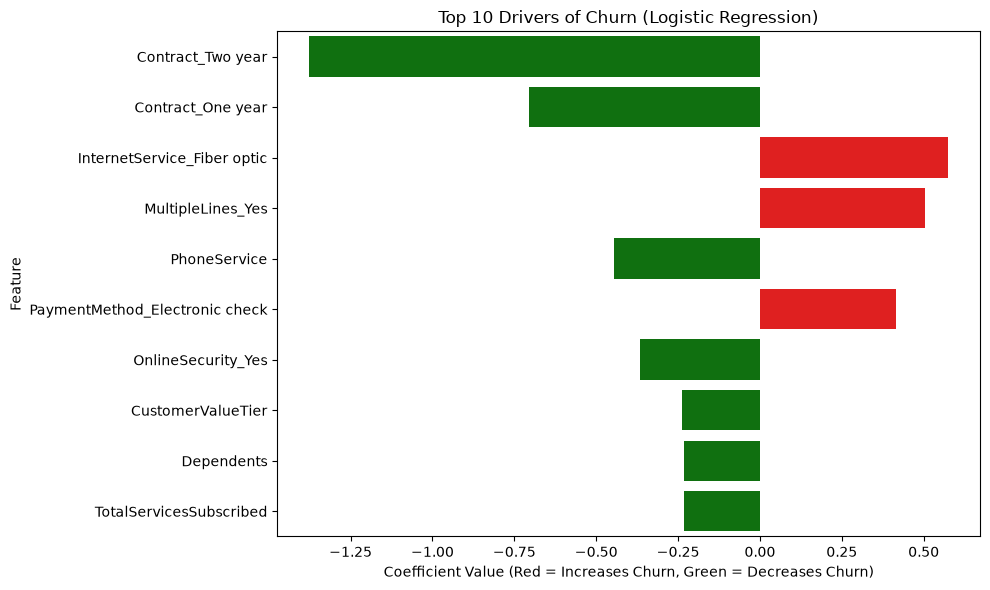

Top 10 Feature Coefficients:


,Feature,Coefficient
30,Contract_Two year,-1.376439
29,Contract_One year,-0.706319
15,InternetService_Fiber optic,0.574369
14,MultipleLines_Yes,0.505230
5,PhoneService,-0.445085
32,PaymentMethod_Electronic check,0.416839
18,OnlineSecurity_Yes,-0.367489
11,CustomerValueTier,-0.238378
3,Dependents,-0.233176
9,TotalServicesSubscribed,-0.233162


In [137]:
# 1. Select Logistic Regression as the best model
best_model_name = "Logistic Regression"
best_model = models[best_model_name]

print(f"✅ Final Production Model Selected: {best_model_name}\n")

# 2. Since it's Logistic Regression, we can easily extract Feature Importances (Coefficients)
# The coefficients tell us how much each feature increases or decreases the likelihood of churn.

# Assuming your features are stored in X_train.columns
feature_names = X_train.columns
coefficients = best_model.coef_[0]

# Create a DataFrame to view the importances clearly
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by absolute value to see the most impactful features (both positive and negative)
feature_importance_df['Abs_Coefficient'] = feature_importance_df['Coefficient'].abs()
feature_importance_df = feature_importance_df.sort_values(by='Abs_Coefficient', ascending=False)

# 3. Plot the top 10 most important features
plt.figure(figsize=(10, 6))
top_10_features = feature_importance_df.head(10)

# Color positive coefficients (increase churn) red, and negative (decrease churn) green
colors = ['red' if coef > 0 else 'green' for coef in top_10_features['Coefficient']]

sns.barplot(x='Coefficient', y='Feature', data=top_10_features, palette=colors)
plt.title(f'Top 10 Drivers of Churn ({best_model_name})')
plt.xlabel('Coefficient Value (Red = Increases Churn, Green = Decreases Churn)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Display the exact numbers
print("Top 10 Feature Coefficients:")
display(top_10_features[['Feature', 'Coefficient']])


In [138]:
import os
import joblib

# Define the save path
save_dir = r"D:\Telco_Customer_Churn\models"
model_filename = "best_churn_model.pkl"
save_path = os.path.join(save_dir, model_filename)

# Create the directory if it doesn't already exist
os.makedirs(save_dir, exist_ok=True)

# Save the best model
# (Assuming 'best_model' was defined in the previous code block)
joblib.dump(best_model, save_path)

print(f"✅ Model successfully saved to: {save_path}")


✅ Model successfully saved to: D:\Telco_Customer_Churn\models\best_churn_model.pkl


# To load the model later
loaded_model = joblib.load(r"D:\Telco_Customer_Churn\models\best_churn_model.pkl")

# Make predictions on new data
# predictions = loaded_model.predict(new_data)
